In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
_ = np.loadtxt('J0_J20_T298_exocross.xsec')
print(_)
wavenumber, cross_sec = _[:, 0], _[:, 1]

__ = np.loadtxt('J0_J20_T500_exocross.xsec')
print(__)
wavenumber_, cross_sec_ = __[:, 0], __[:, 1]

___ = np.loadtxt('J0_J20_T1000_exocross.xsec')
print(___)
wavenumber__, cross_sec__ = ___[:, 0], ___[:, 1]

[[0.00000000e+00 1.70807487e-24]
 [5.00000000e-01 6.88560942e-24]
 [1.00000000e+00 2.19442665e-23]
 ...
 [9.99900000e+03 9.07294054e-30]
 [9.99950000e+03 2.31773336e-30]
 [1.00000000e+04 2.00398428e-31]]
[[0.00000000e+00 1.42811745e-24]
 [5.00000000e-01 5.38561041e-24]
 [1.00000000e+00 1.56387623e-23]
 ...
 [9.99900000e+03 3.94486308e-30]
 [9.99950000e+03 1.00754072e-30]
 [1.00000000e+04 8.71130963e-32]]
[[0.00000000e+00 2.92485773e-24]
 [5.00000000e-01 8.86167855e-24]
 [1.00000000e+00 1.89275550e-23]
 ...
 [9.99900000e+03 7.06050979e-31]
 [9.99950000e+03 1.80303496e-31]
 [1.00000000e+04 1.55889766e-32]]


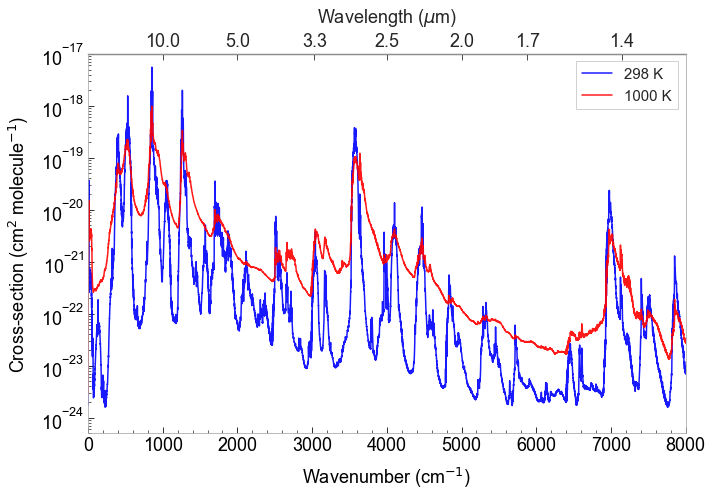

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.style.use('seaborn-v0_8-white')  # No gridlines

# Plot (other colors, #2196F3, #8E24AA, #E53935)
ax.plot(wavenumber,  cross_sec,  color='blue', linewidth=1.5, label='298 K', alpha=0.9)
#ax.plot(wavenumber_, cross_sec_, color='darkorange', linewidth=1.5, label='500 K', alpha=0.9)
ax.plot(wavenumber__, cross_sec__, color='red', linewidth=1.5, label='1000 K', alpha=0.9)

# Log scale & axis limits
ax.set_yscale('log')
ax.set_xlim(0, 8000)
ax.set_ylim(0.5e-24, 1e-17)

# Primary x-axis (wavenumber)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=18, labelpad=10)
ax.set_ylabel(r'Cross-section (cm$^{2}$ molecule$^{-1}$)', fontsize=18, labelpad=10)
#ax.set_title('Absorption Cross-Sections', fontsize=16, fontweight='bold', pad=40)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=6)
ax.tick_params(axis='both', which='minor', direction='in', length=3)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

# ── Secondary x-axis: wavelength (μm) ────────────────────────────────────────
# Wavelength (μm) = 10 000 / wavenumber (cm⁻¹); nonlinear so we set explicit ticks
ax_top = ax.secondary_xaxis('top')

# Choose round wavelength values (μm) that fall within xlim (0–5000 cm⁻¹)
wl_ticks_um = np.round(10000/np.arange(1000,10000,1000), decimals=1) # μm
wn_positions = 10000 / wl_ticks_um   # cm⁻¹ positions

ax_top.set_xticks(wn_positions)
ax_top.set_xticklabels([str(w) for w in wl_ticks_um], fontsize=18)
ax_top.set_xlabel(r'Wavelength ($\mu$m)', fontsize=18, labelpad=10)
ax_top.tick_params(which='major', direction='in', length=6)

# Legend
ax.legend(
    fontsize=15,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fancybox=False,
    loc='best'
)

# Subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('HOPO_J0_J20_cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()

## Stick Spectra

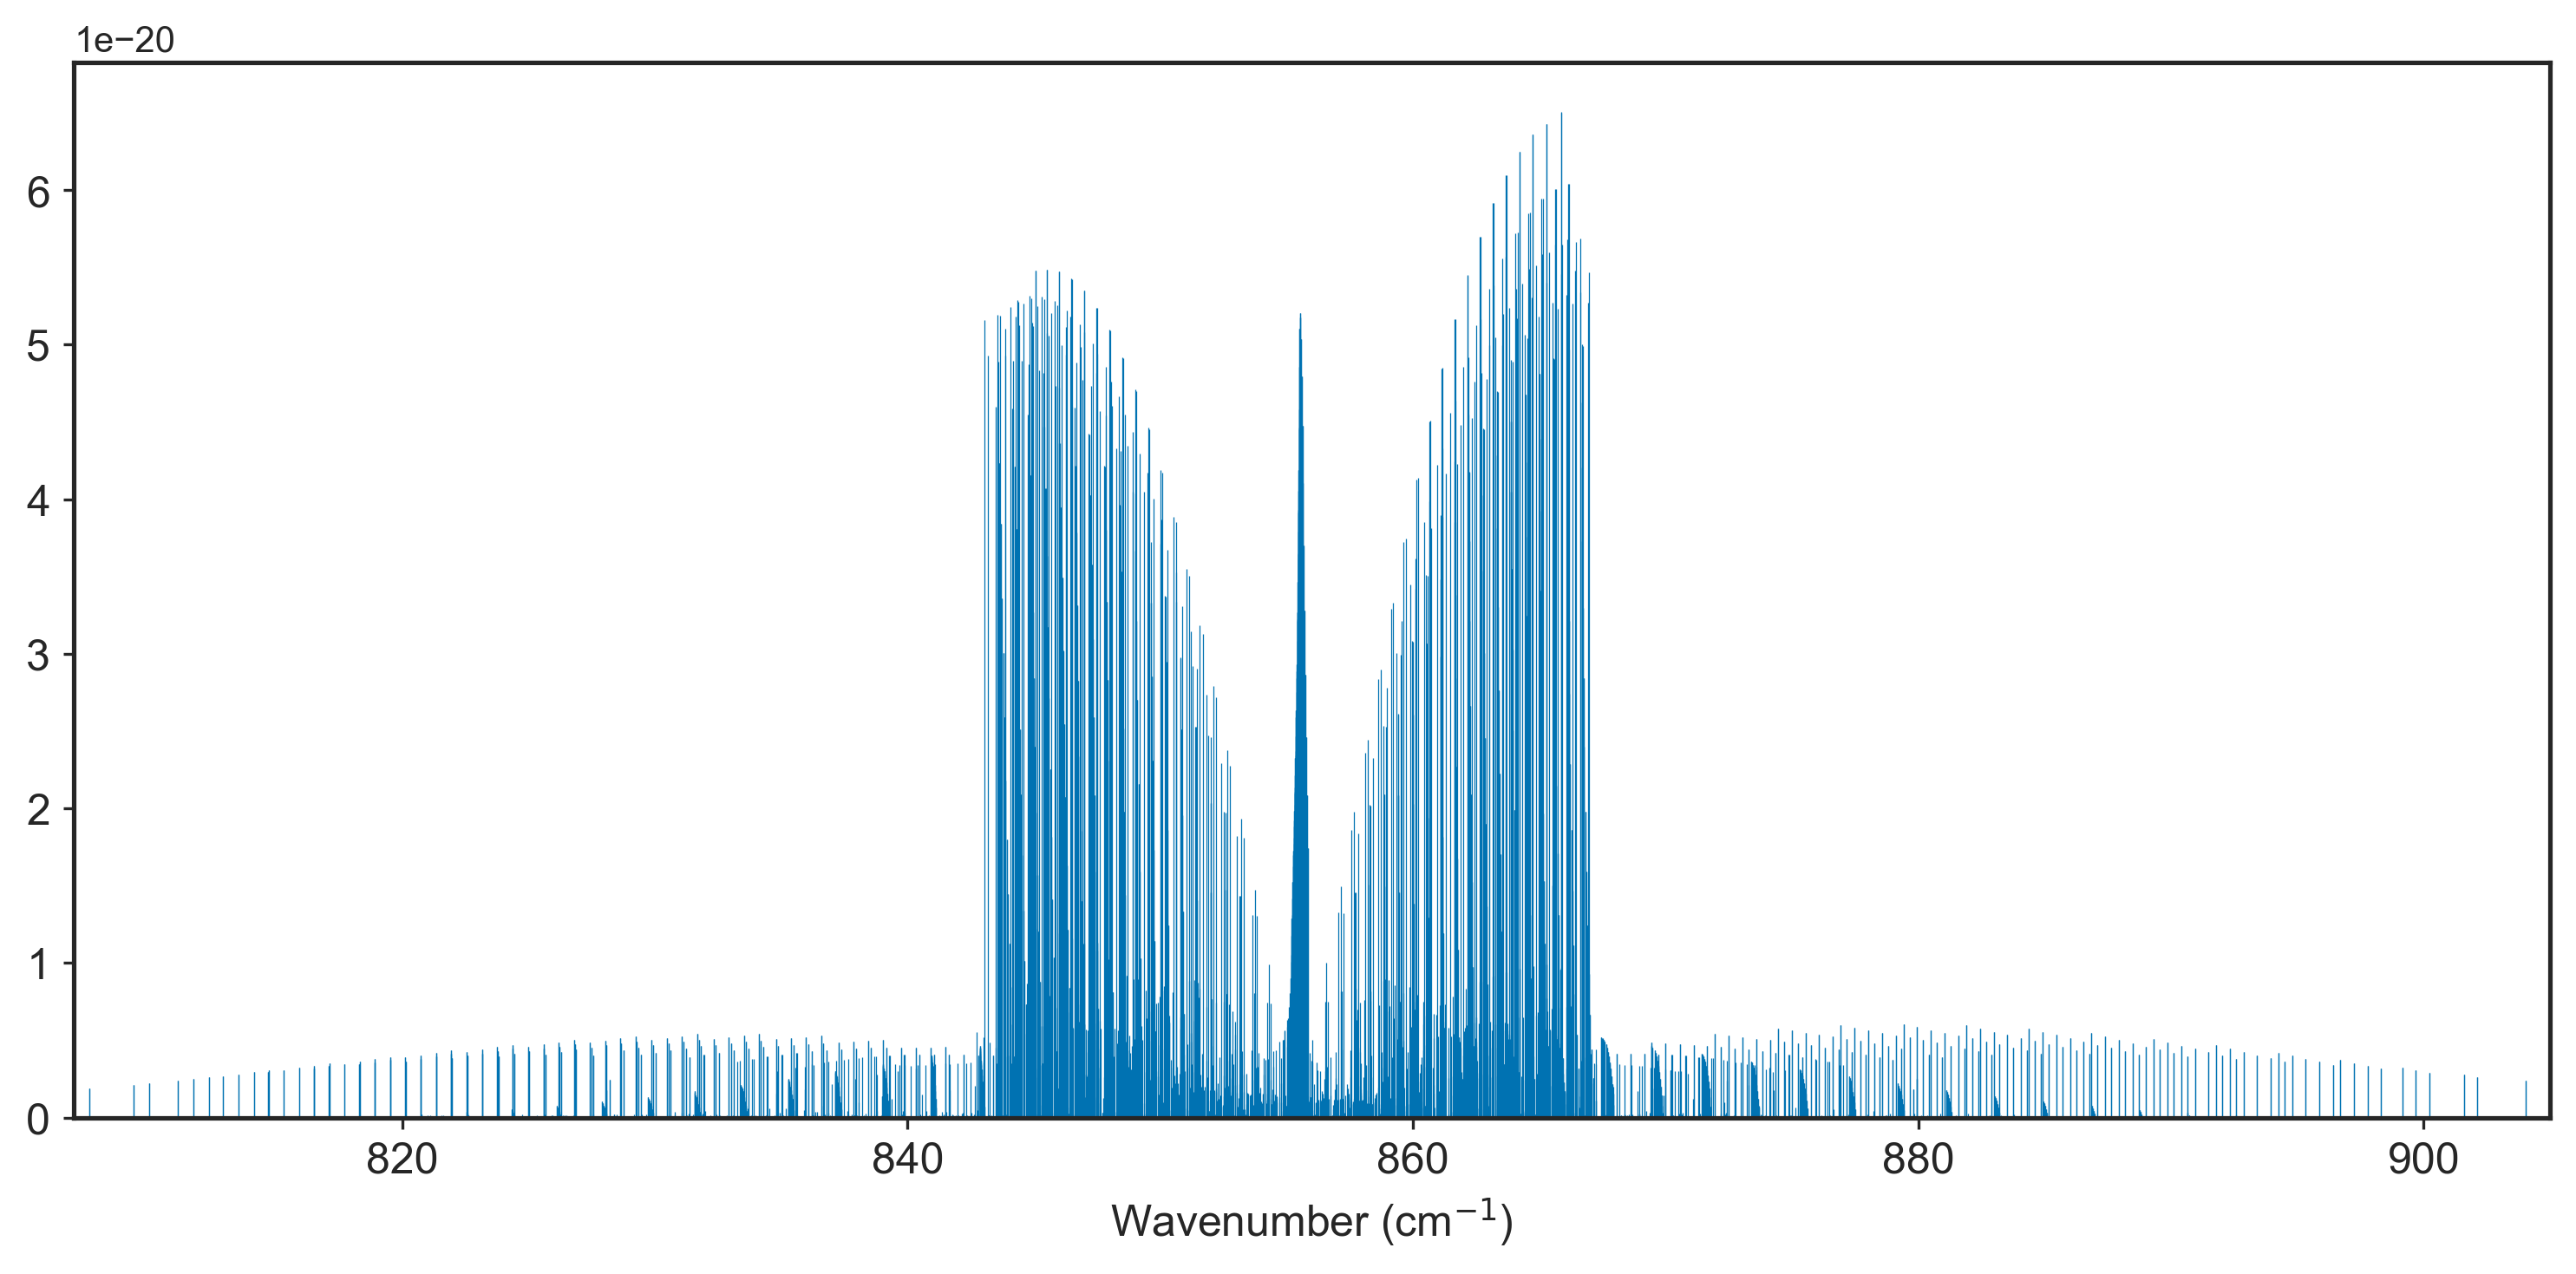

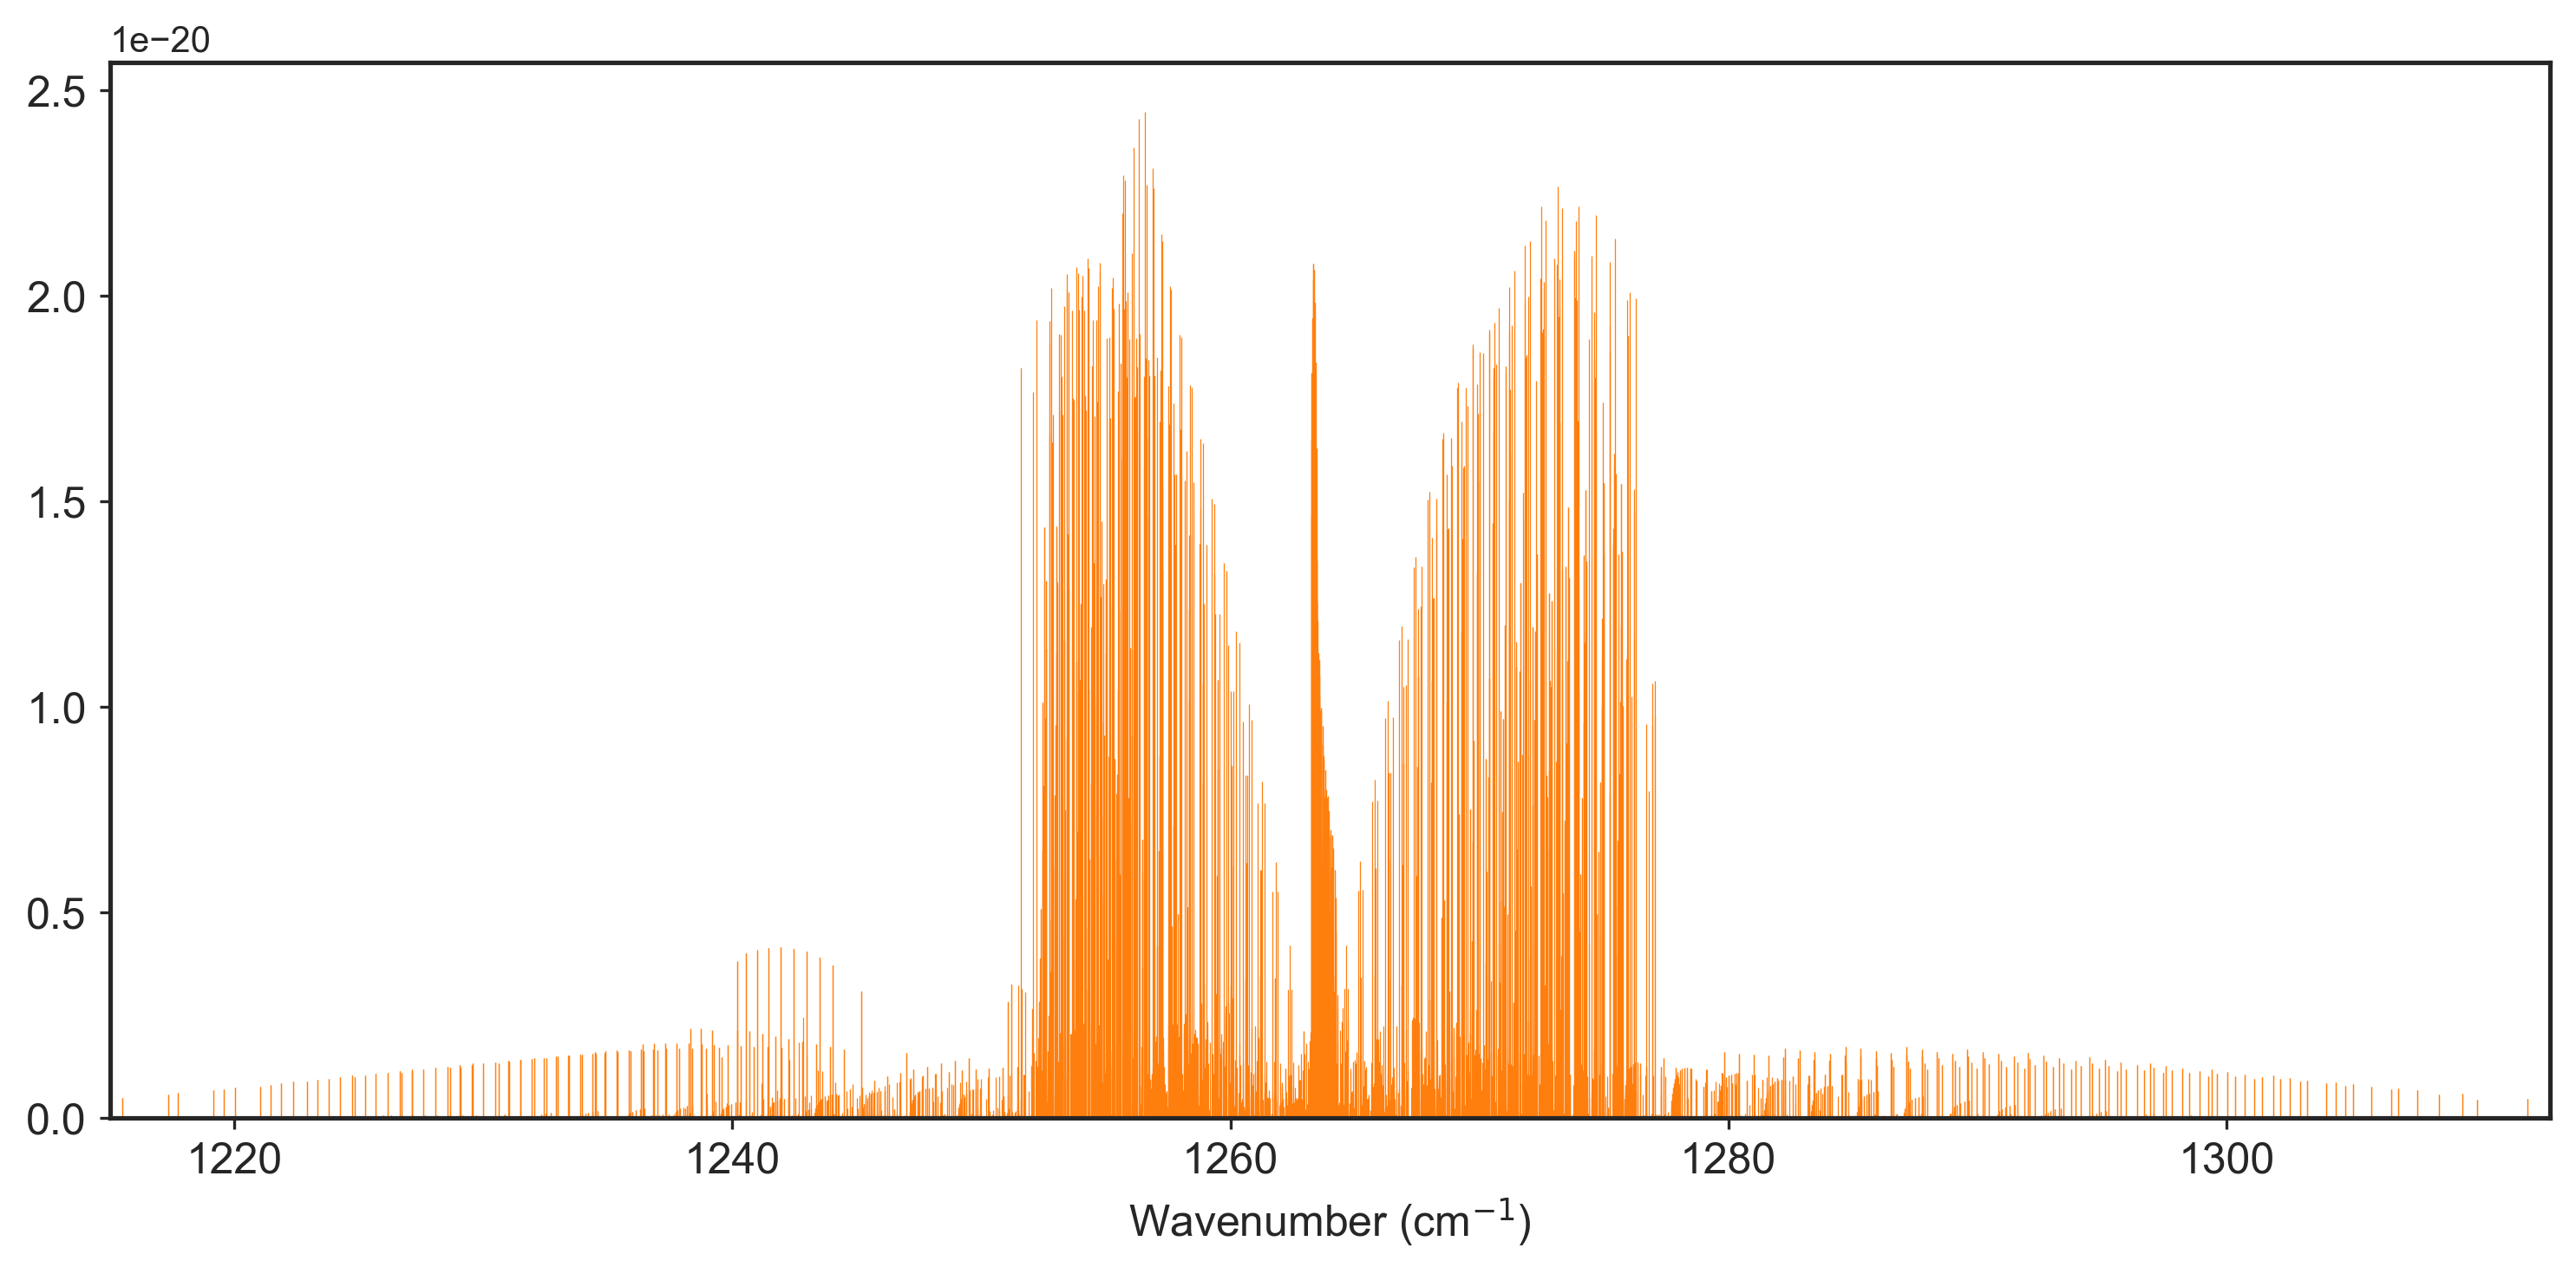

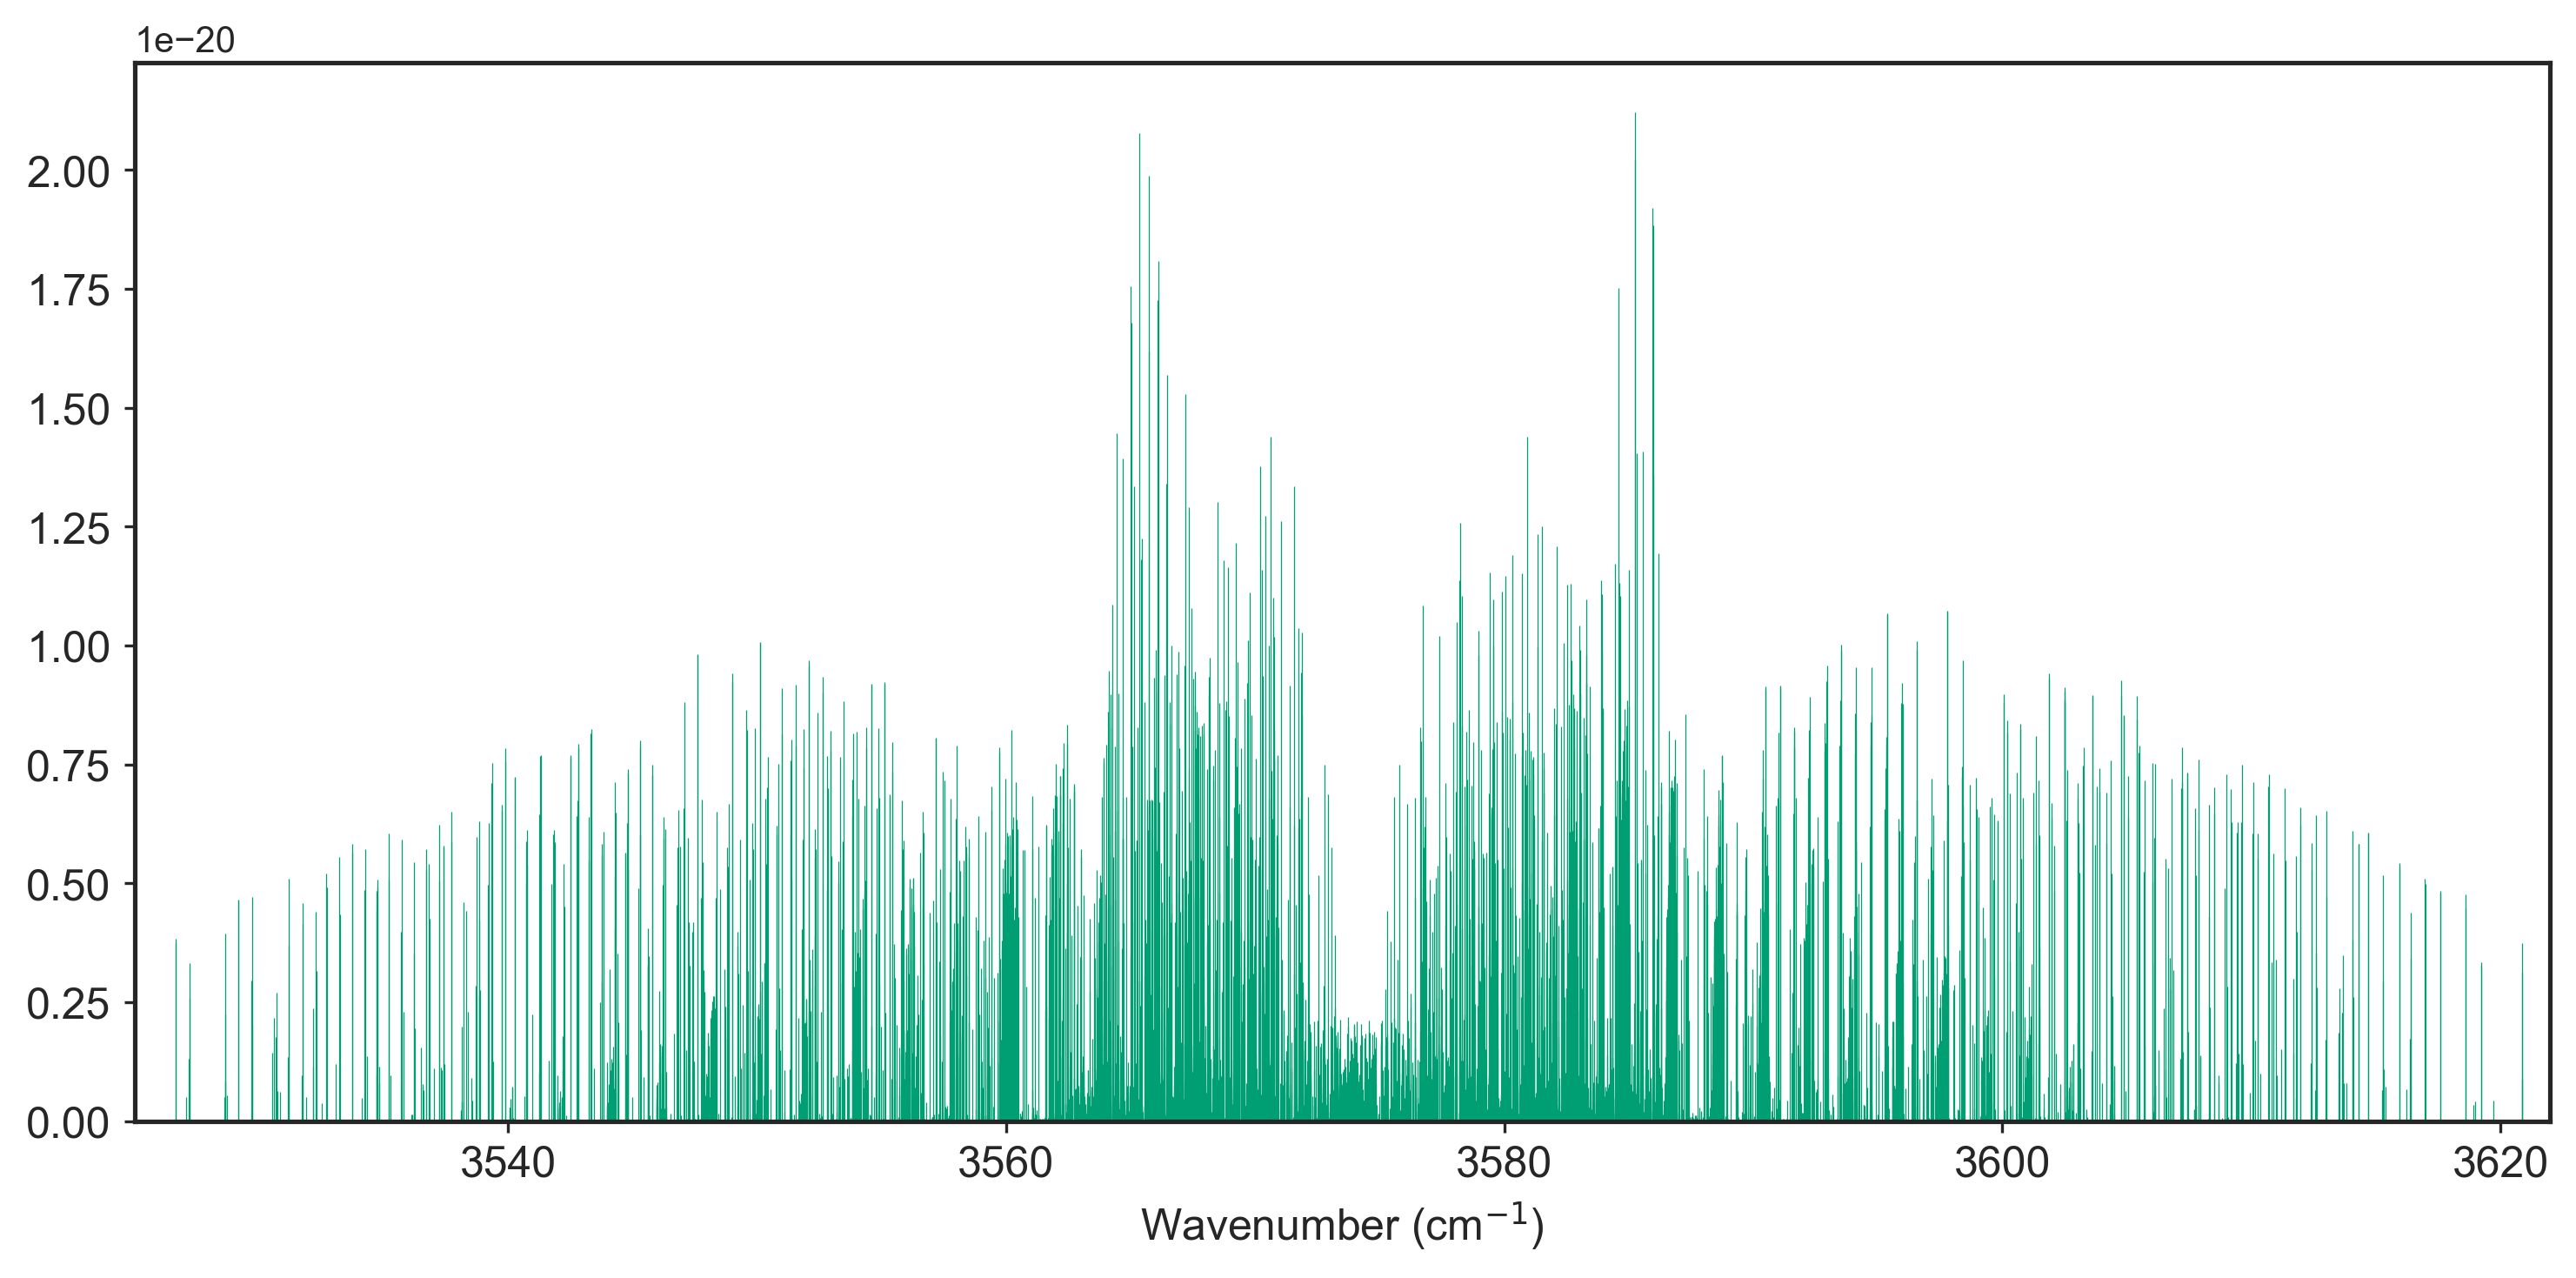

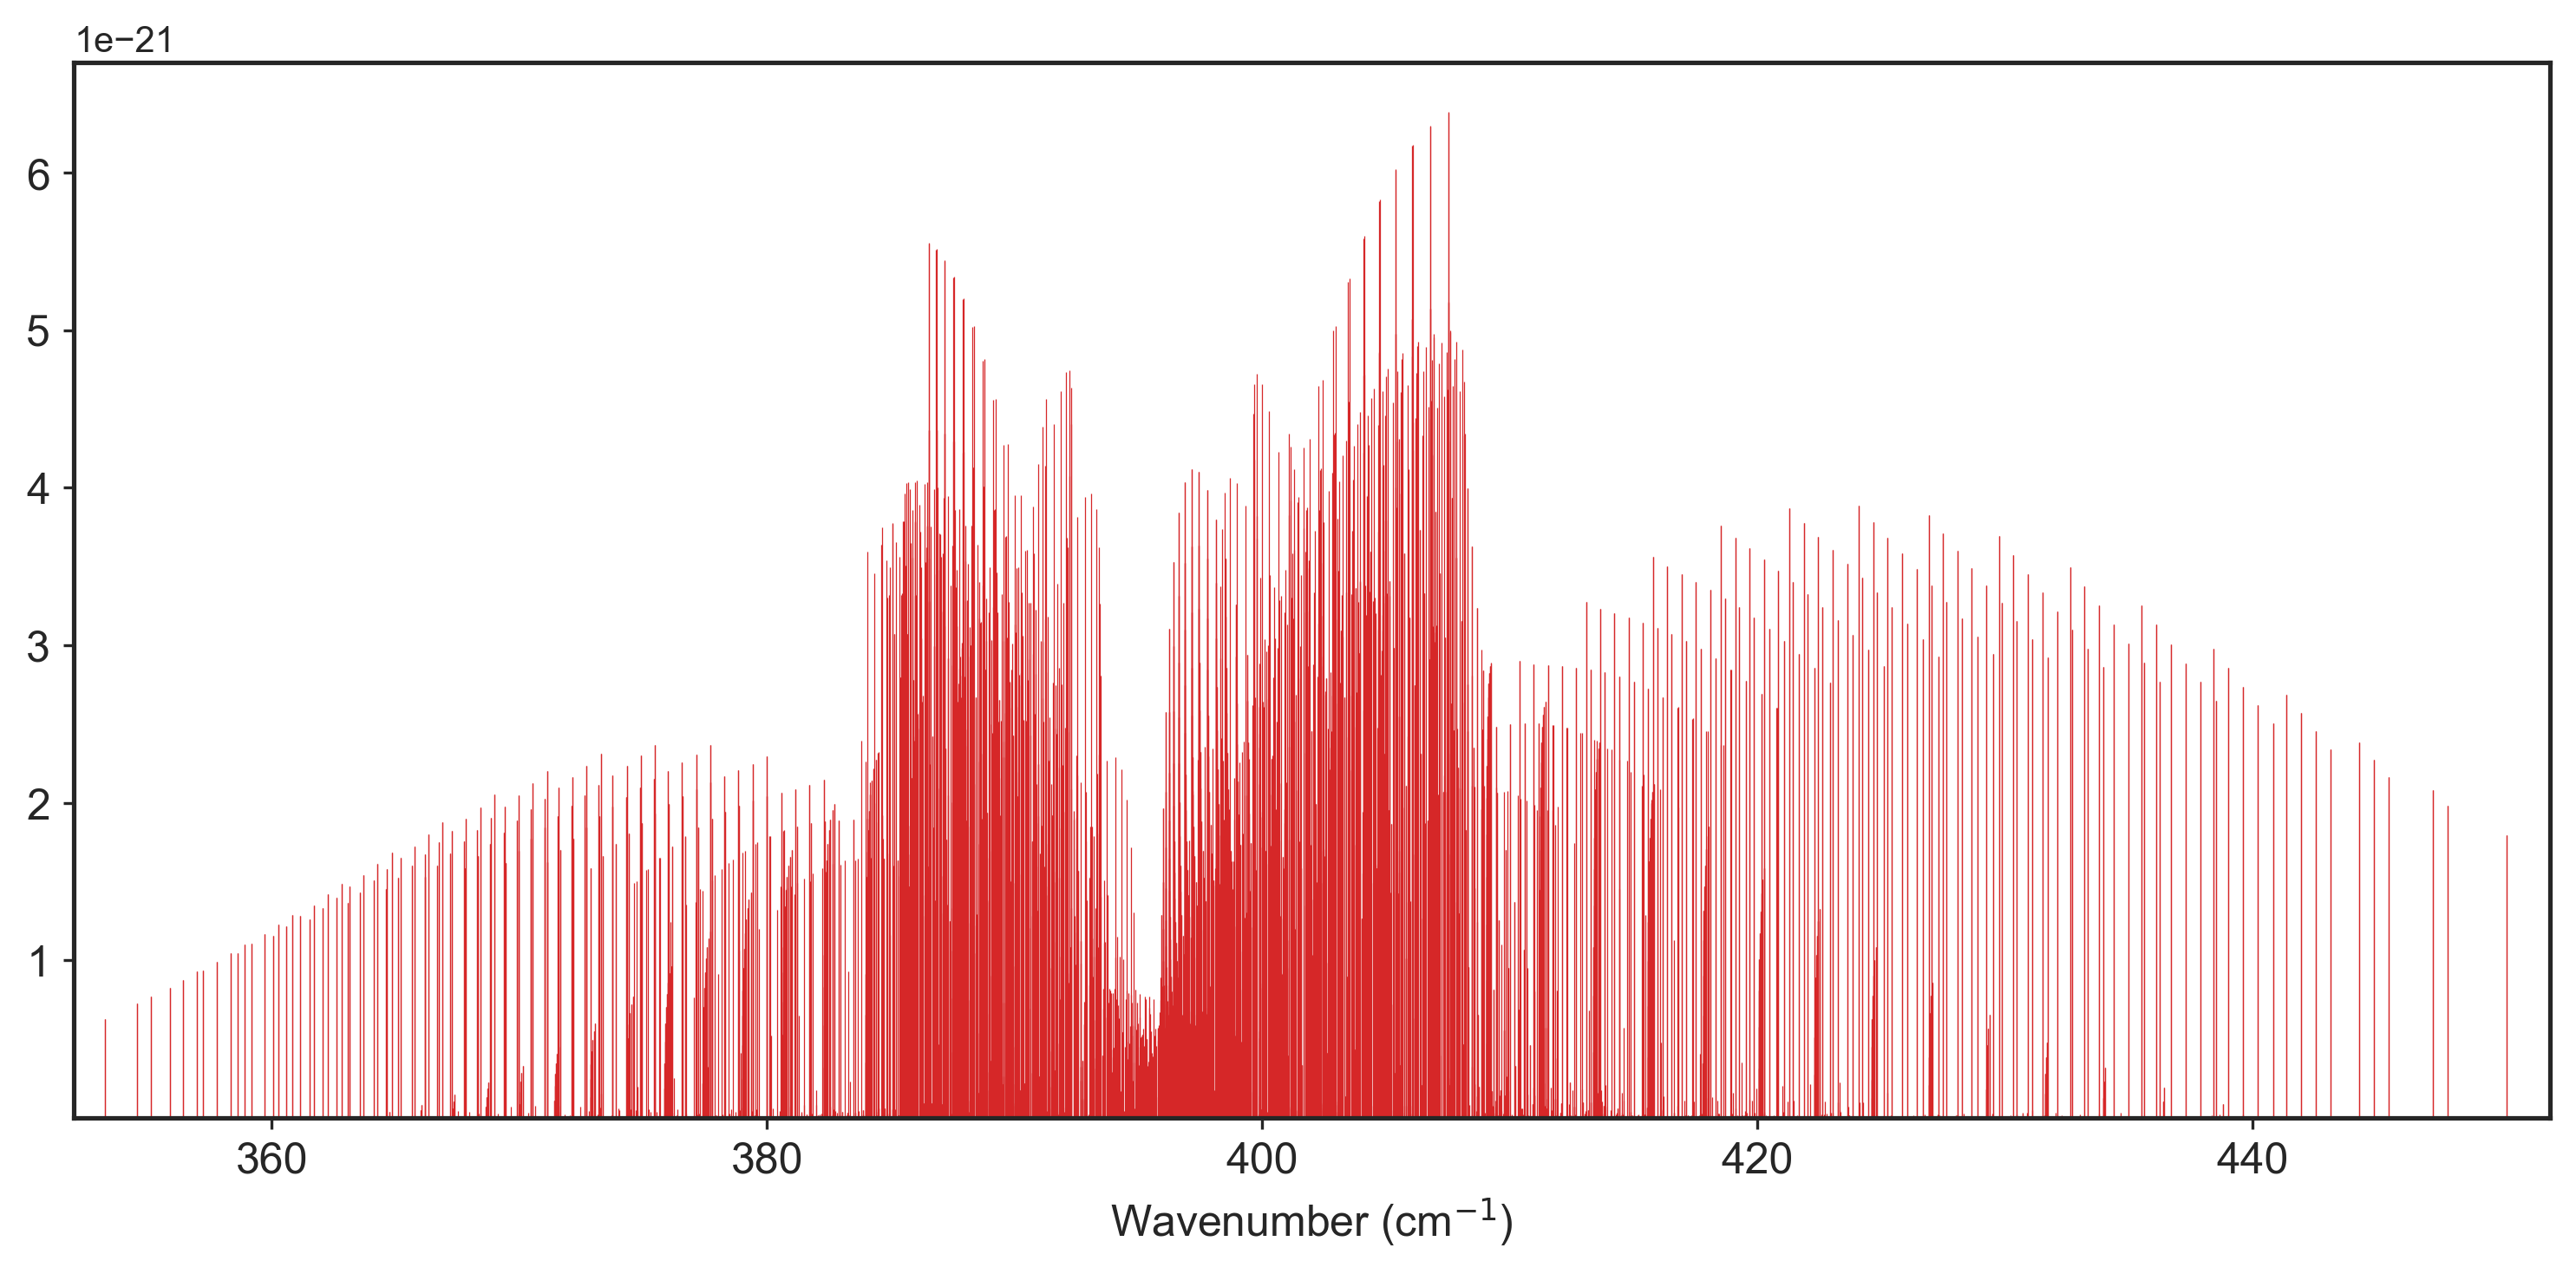

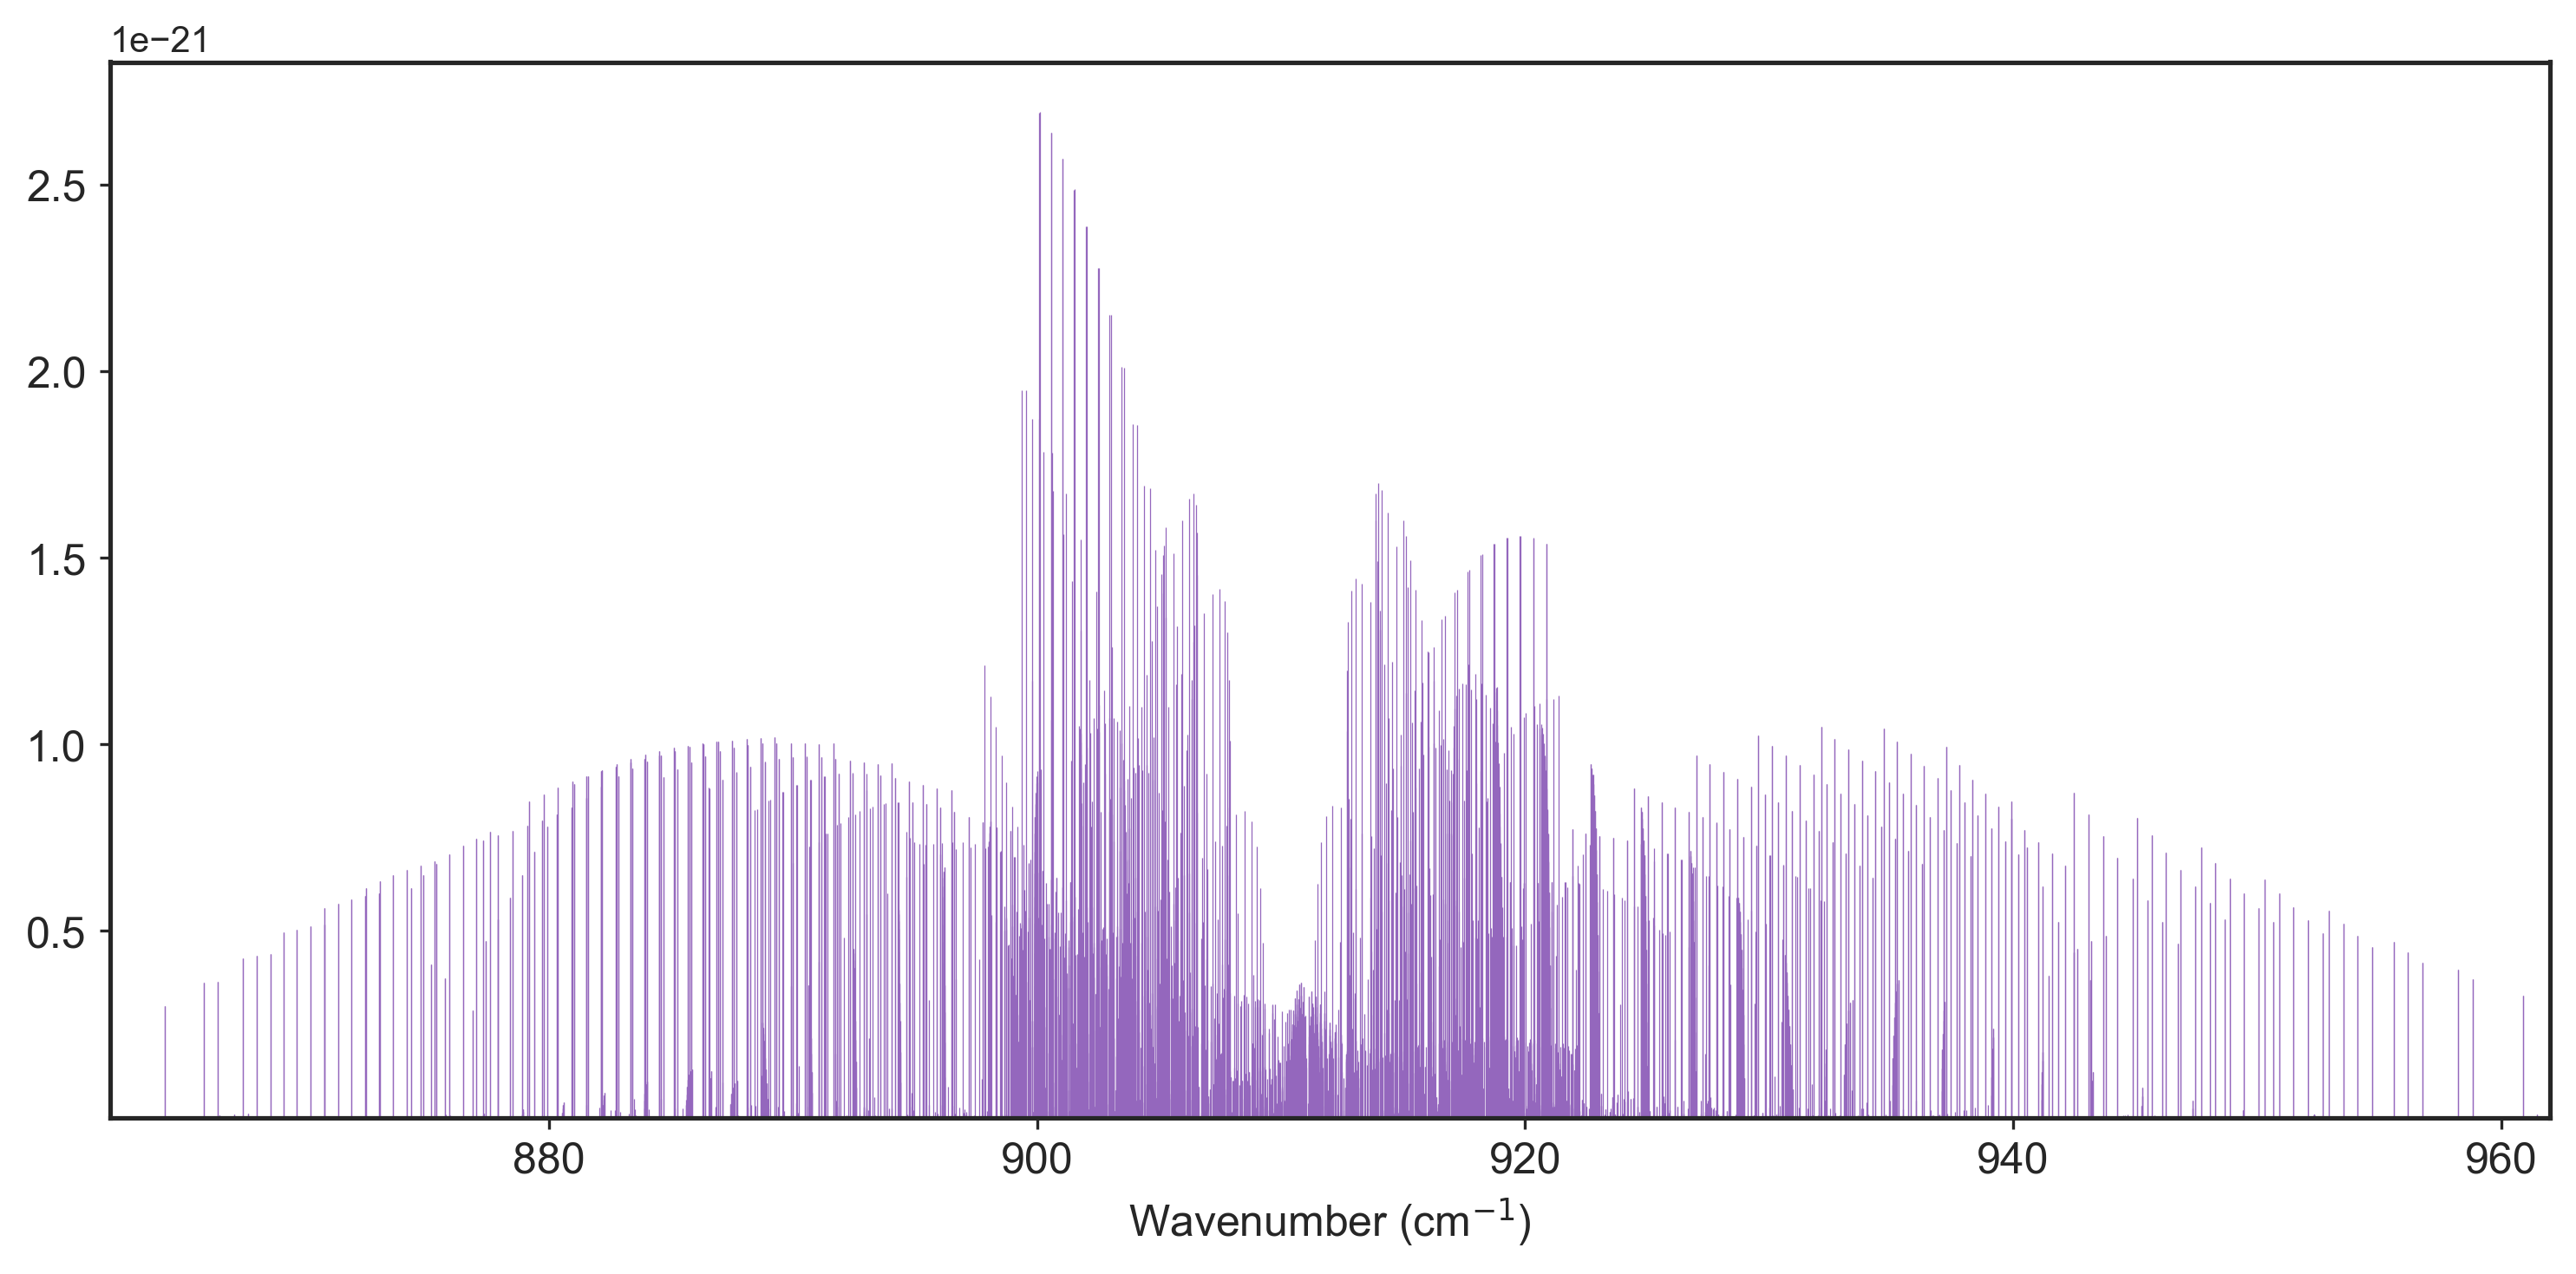

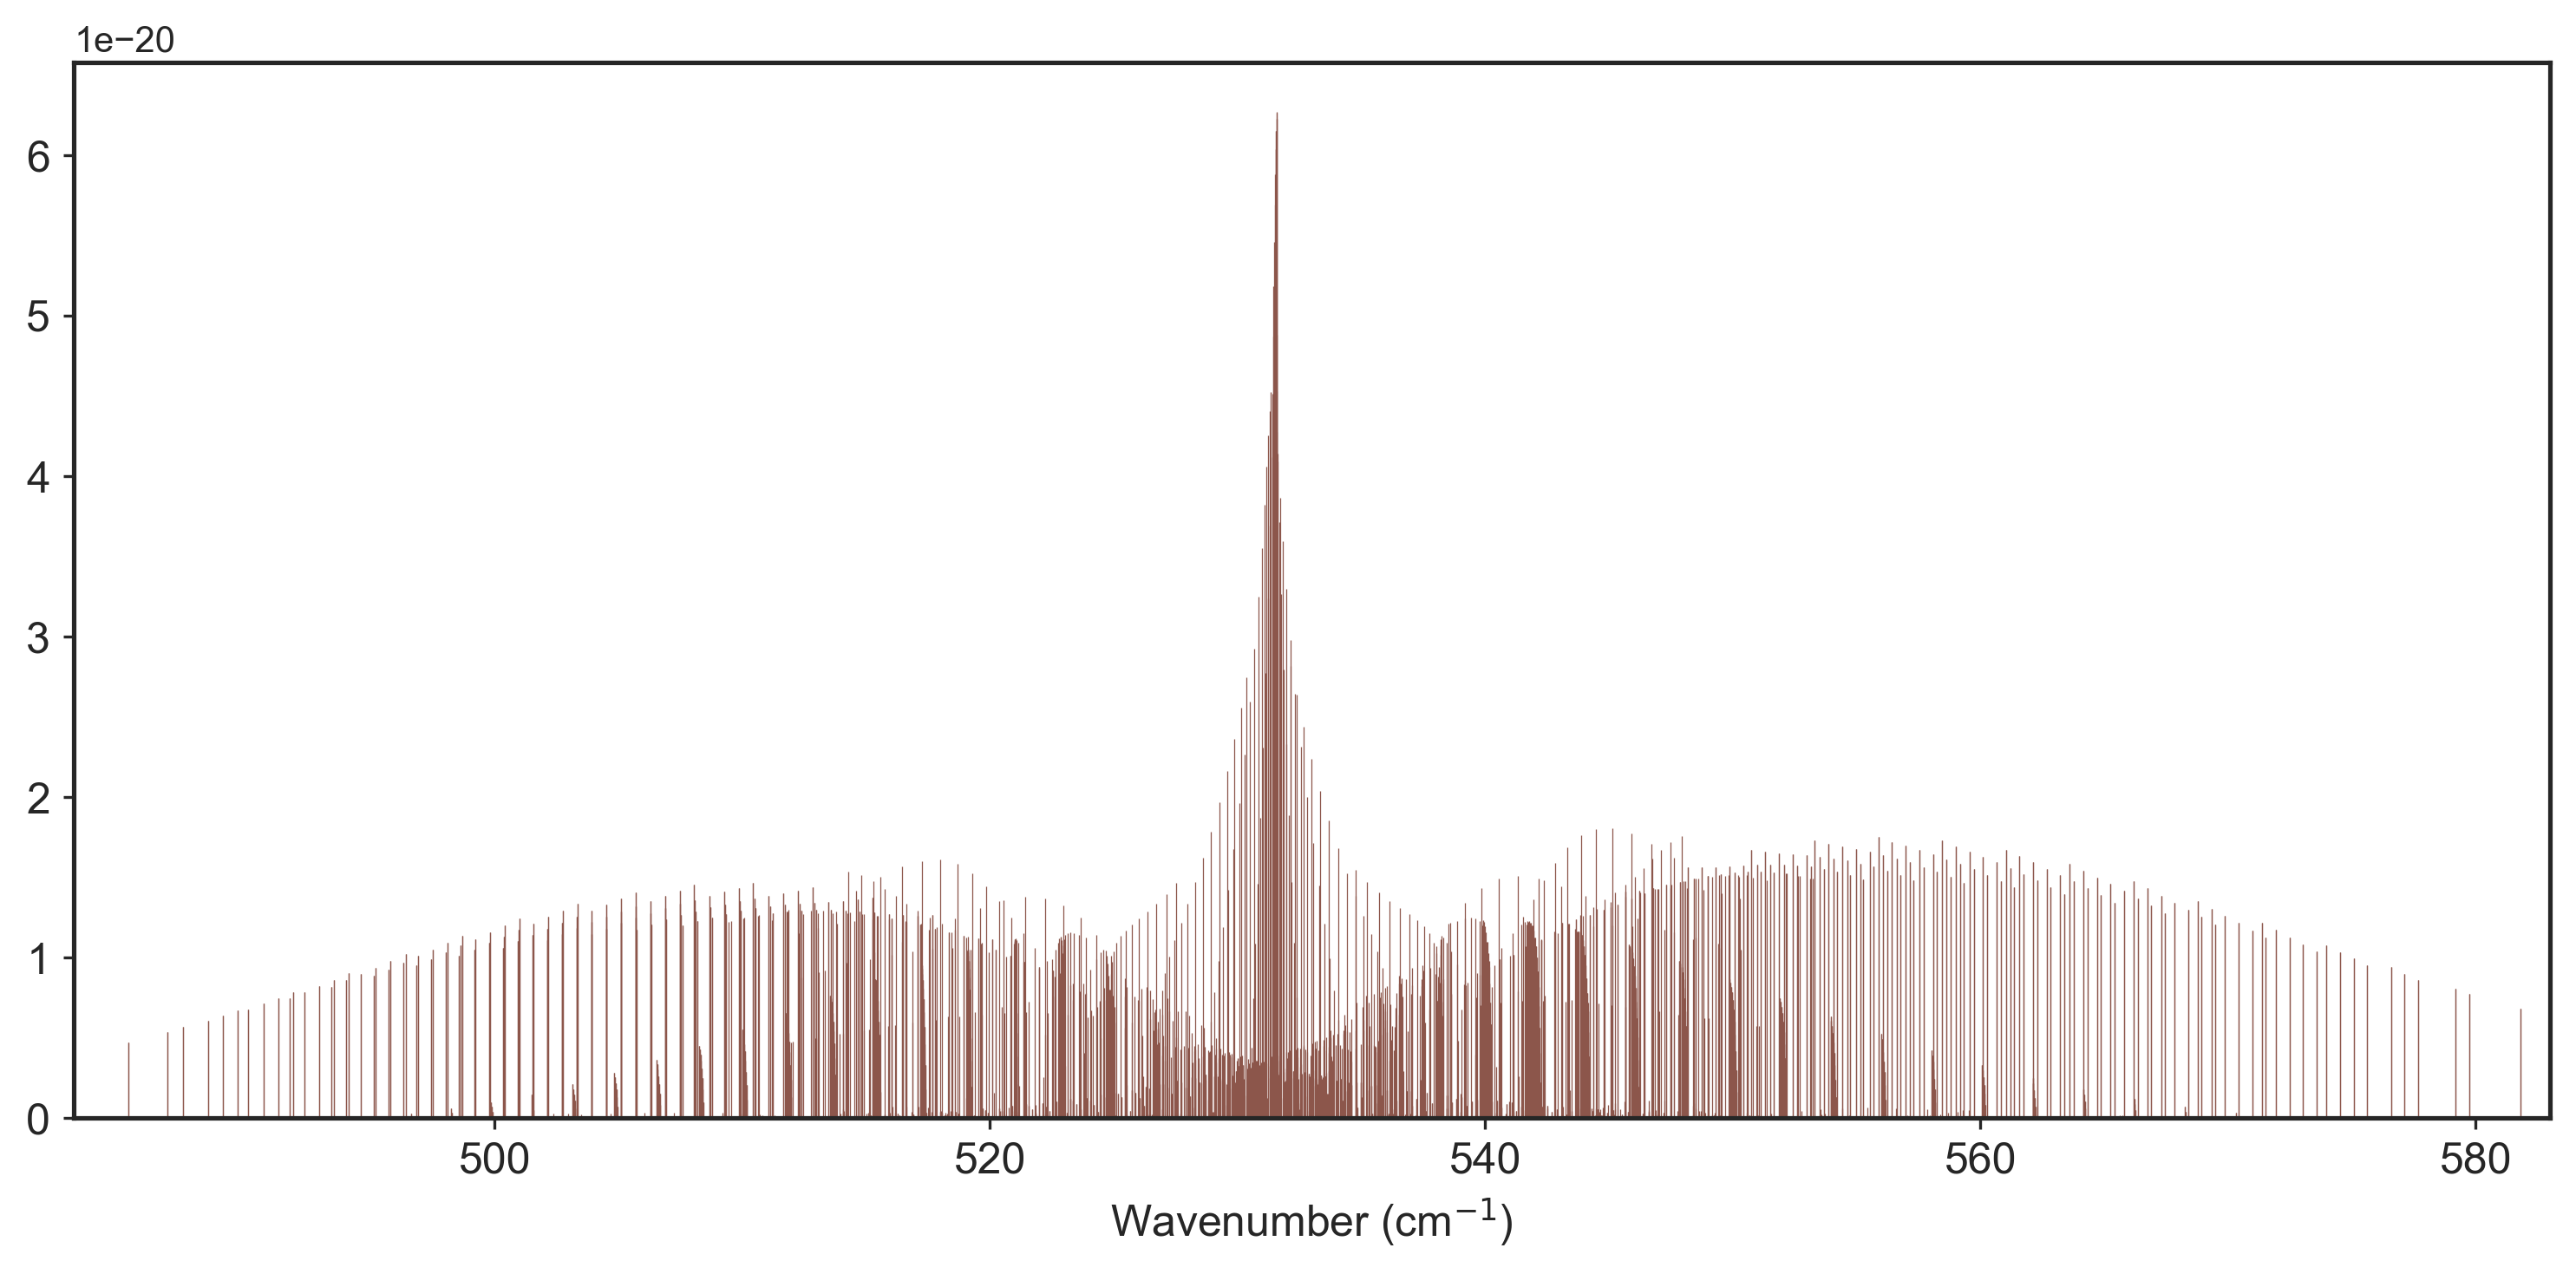

In [62]:
x_lower = [807, 1215, 3525, 352, 862, 483]
x_upper = [905, 1313, 3622, 452, 962, 583]
colors = ["#0072B2", "#ff7f0e", "#009E73", "#d62728", "#9467bd", "#8c564b"]
#colors= ["#1f77b4", "#E69F00", "#2ca02c", "#D55E00", "#CC79A7", "#56B4E9"]


for i in range(1,7):
    file_name = f'J0_J20_T298_stickfilter_exocross_{i}.stick'
    stick_xsec = np.loadtxt(file_name)
    stick_wave, stick_cross = stick_xsec[:, 0], stick_xsec[:, 1]
    
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
    
    markerline, stemlines, baseline = ax.stem(
            stick_wave, stick_cross,
            linefmt=colors[i-1],
            markerfmt=' ',          # hides the markers entirely
            basefmt='k-',           # solid black baseline
            bottom=1e-30
            )
    ax.set_ylim(bottom=1e-30)
    ax.set_xlim(x_lower[i-1], x_upper[i-1])
    
    ax.set_xlabel('Wavenumber (cm$^{-1}$)', fontsize=12)
    
    # Fine-tune line width after creation
    plt.setp(stemlines, linewidth=0.3, alpha=1.0)
    plt.setp(baseline, linewidth=0.8)
    
    ax.tick_params(axis='both', which='major', labelsize=12, direction='out', length=3)
    #ax.tick_params(axis='both', which='minor', direction='out', length=3)

    plt.tight_layout()
    plt.show()

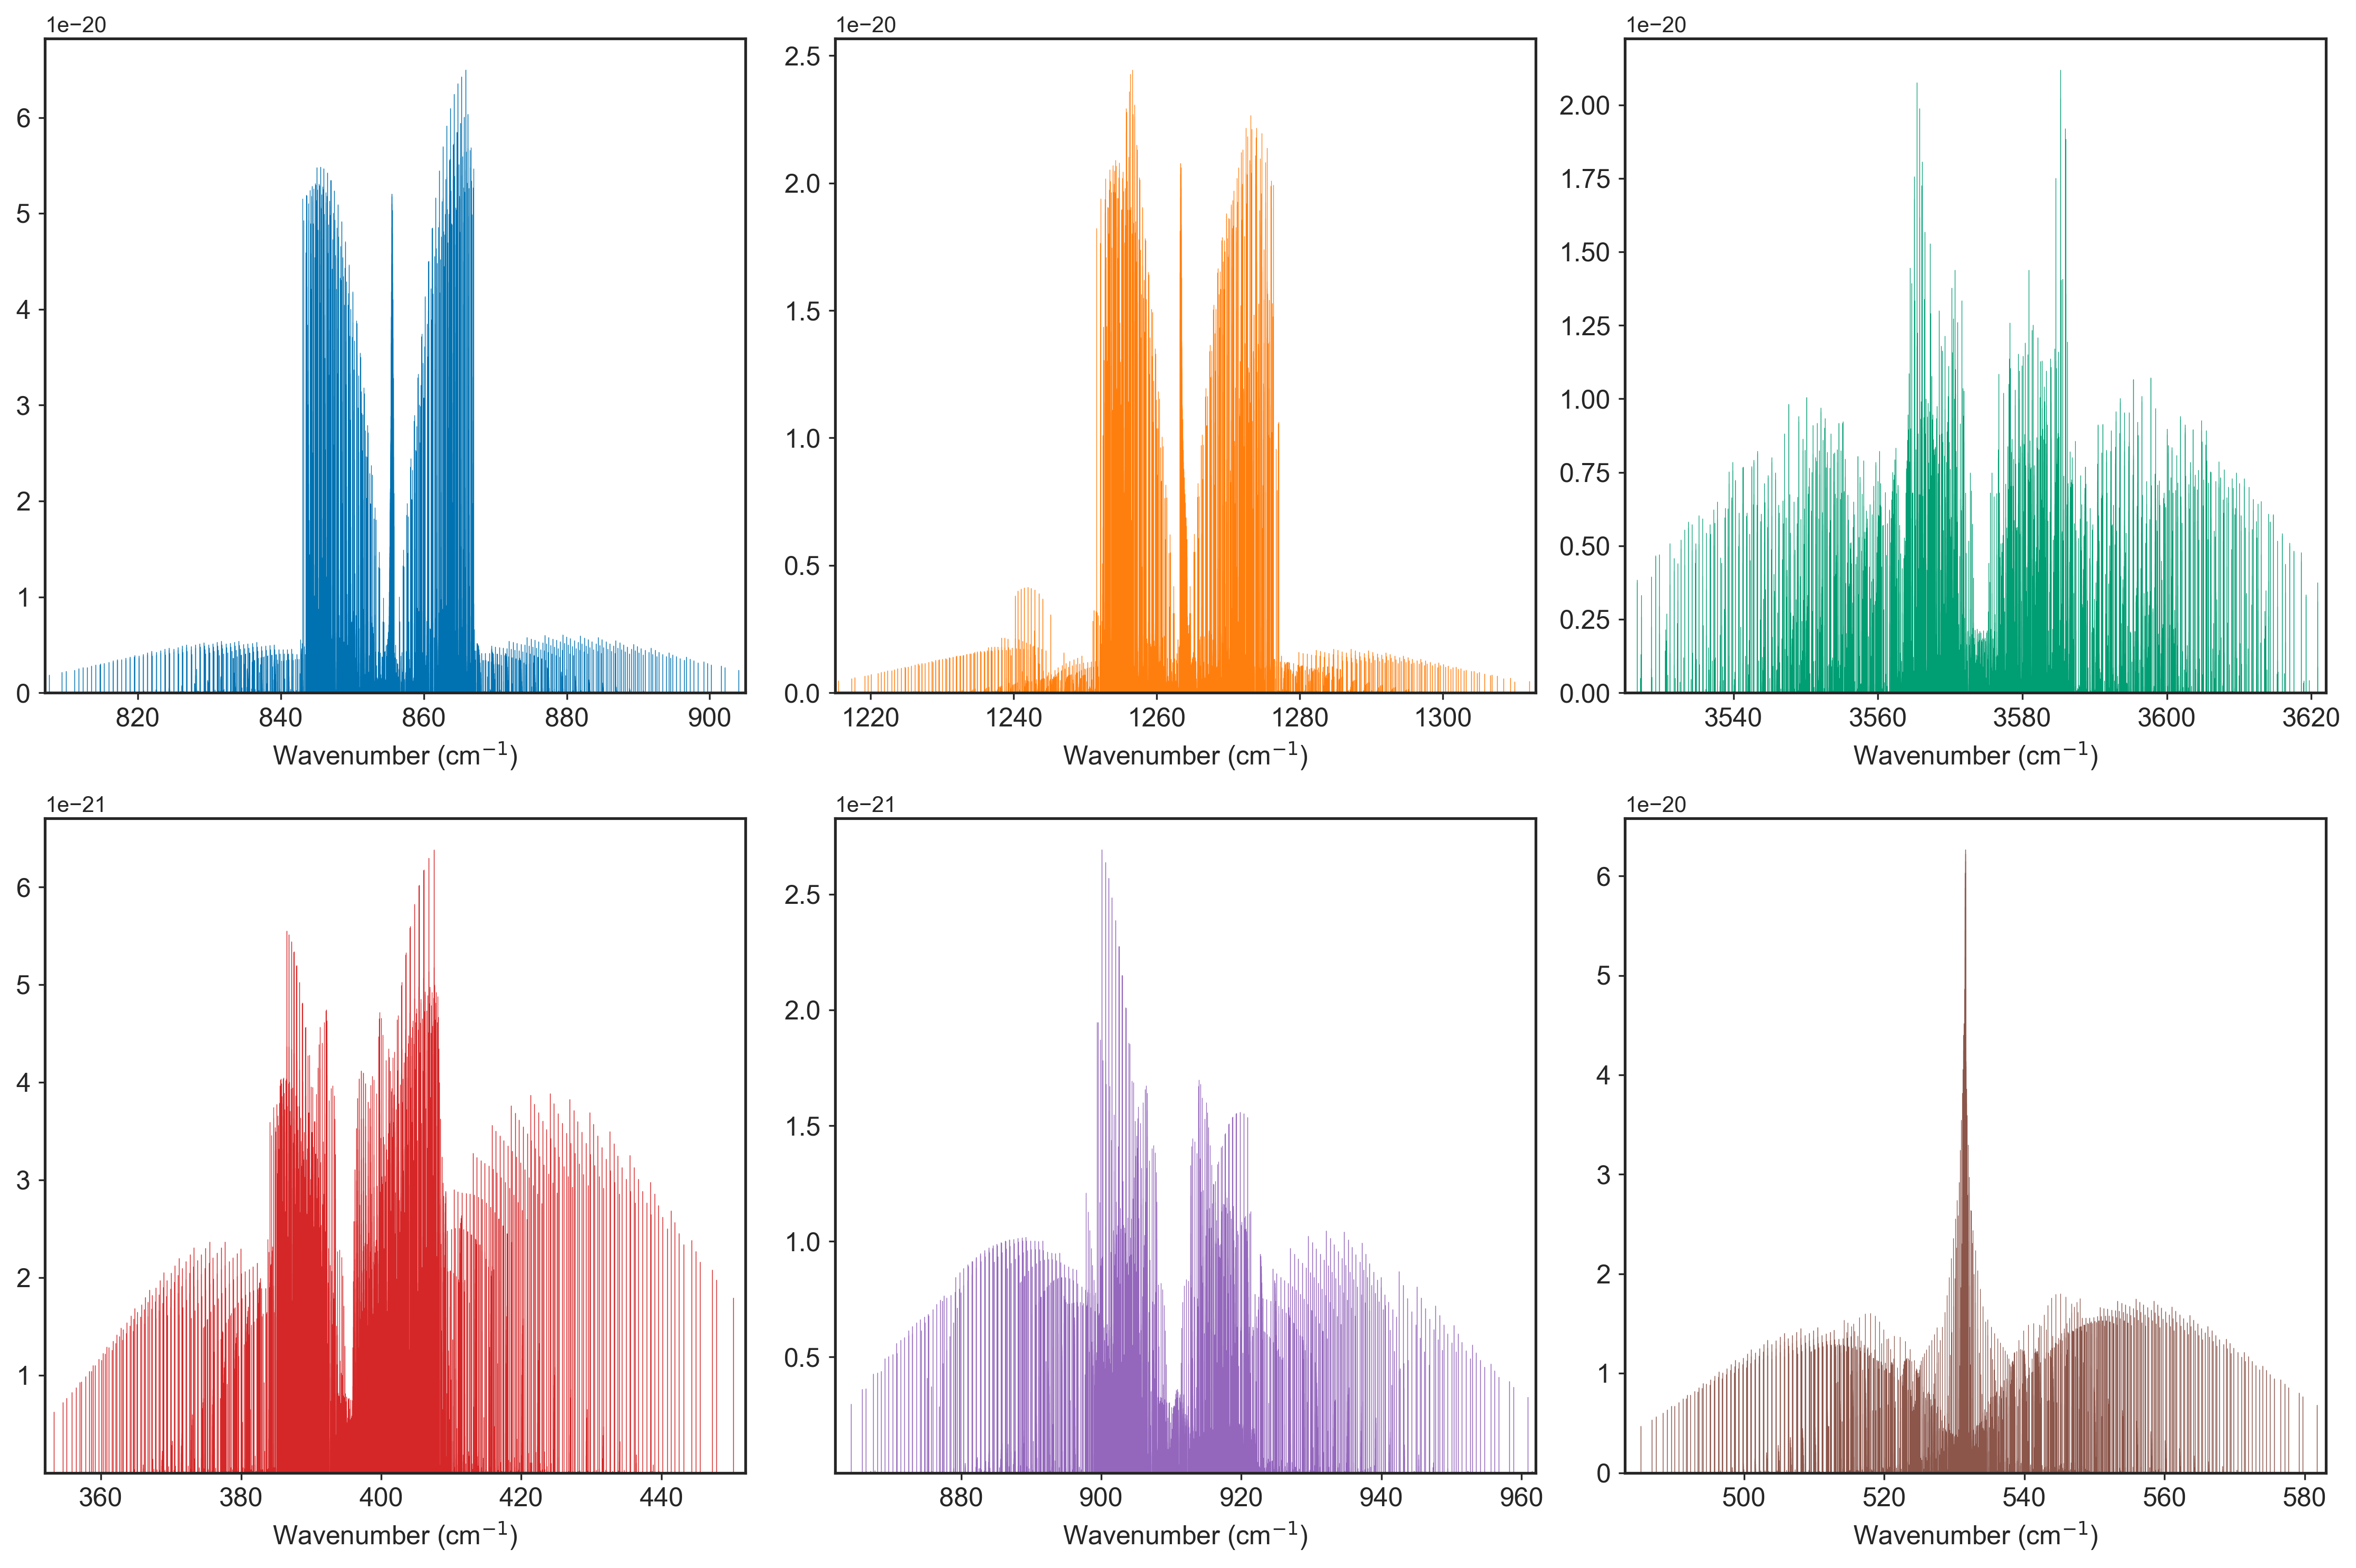

In [65]:
x_lower = [807, 1215, 3525, 352, 862, 483]
x_upper = [905, 1313, 3622, 452, 962, 583]
colors = ["#0072B2", "#ff7f0e", "#009E73", "#d62728", "#9467bd", "#8c564b"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=300)
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i in range(1, 7):
    file_name = f'J0_J20_T298_stickfilter_exocross_{i}.stick'
    stick_xsec = np.loadtxt(file_name)
    stick_wave, stick_cross = stick_xsec[:, 0], stick_xsec[:, 1]

    ax = axes[i - 1]

    markerline, stemlines, baseline = ax.stem(
        stick_wave, stick_cross,
        linefmt=colors[i - 1],
        markerfmt=' ',
        basefmt='k-',
        bottom=1e-30
    )
    ax.set_ylim(bottom=1e-30)
    ax.set_xlim(x_lower[i - 1], x_upper[i - 1])

    ax.set_xlabel('Wavenumber (cm$^{-1}$)', fontsize=12)

    plt.setp(stemlines, linewidth=0.3, alpha=1.0)
    plt.setp(baseline, linewidth=0.8)

    ax.tick_params(axis='both', which='major', labelsize=12, direction='out', length=3)

plt.tight_layout()
plt.show()